In [6]:
# Decision Tree

# max_depth=2
# max_depth=10

# 둘 다 같은 알고리즘인데 결과가 다름
# ↓
# 좋은 값을 자동으로 찾자
# ↓
# Grid Search

In [7]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = load_iris()

X = iris.data
y = iris.target

x_train,x_test,y_train,y_test = train_test_split(
    X,
    y,
    random_state=42
)

for depth in [1,2,3,4,5]:

    model = DecisionTreeClassifier(
        max_depth=depth
    )

    model.fit(
        x_train,
        y_train
    )

    pred = model.predict(
        x_test
    )

    score = accuracy_score(
        y_test,
        pred
    )

    print(depth, score)

1 0.6842105263157895
2 0.9736842105263158
3 1.0
4 1.0
5 1.0


In [ ]:
# 2교시

from sklearn.model_selection import GridSearchCV

param_grid={
    "max_depth":[1,2,3,4,5]
}

grid = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid,
    cv=5
)

grid.fit(x_train,y_train)
print(grid.best_params_)
print(grid.best_score_)

y_pred = grid.predict(x_test) 
print(y_pred)

score = accuracy_score( y_test,y_pred)
print(score)

{'max_depth': 4}
0.9367588932806324
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0]
1.0


In [9]:
# 교차검증 -> 3교시 

전체 데이터
□□□□□□□□□□□□□□□□□□□□

Fold1
[■■■■][□]

Fold2
[■■■][□][■]

Fold3
[■■][□][■■]

Fold4
[■][□][■■■]

Fold5
[□][■■■■] 

1회전 (for 1)

Train
[3][4][5][6][7][8][9][10]

Validation
[1][2]

model.fit(
    [3~10]
)

score=model.score(
    [1,2]
)

2회전 (for 2)
Train
[1][2][5][6][7][8][9][10]

Validation
[3][4]

model.fit(
    나머지
)

score=model.score(
    [3,4]
)
## 실제 돌아 가는 횟수
depth=2
 ├ fold1
 ├ fold2
 ├ fold3
 ├ fold4
 └ fold5

depth=3
 ├ fold1
 ├ fold2
 ├ fold3
 ├ fold4
 └ fold5

depth=4
 ├ fold1
 ├ fold2
 ├ fold3
 ├ fold4
 └ fold5

총  3×5=15 번 돌아감


In [ ]:
# 4 교시 => 과적합 분석

# 4교시 — 과적합 분석 실습 (붓꽃 데이터 + GridSearchCV)

# 목표:

# Train 점수 ↑
# Test 점수 ↓

# 이 현상을 보고 과적합(Overfitting) 을 찾는다.


In [10]:
return_train_score=True #를 켜야 과적합 분석 가능

param_grid = {
    "max_depth":[
        1,
        2,
        3,
        4,
        5,
        10,
        None
    ]

}


grid = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid,
    cv=5,
    return_train_score=True
)


grid.fit(x_train,y_train)


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [1, 2, 3, 4, 5, 10, None]},
             return_train_score=True)

In [ ]:
# 결과보기
import pandas as pd

result = pd.DataFrame(grid.cv_results_) 
result = result[[ "param_max_depth", "mean_train_score", "mean_test_score" ]] 
print(result)

# 4단계 — 과적합 판정

# 판단 기준

# Train    Test	   판정
# 낮음	    낮음	언더피팅
# 높음	    높음	좋음
# 매우 높음	 낮음	 과적합

  param_max_depth  mean_train_score  mean_test_score
0               1          0.660724         0.660870
1               2          0.953084         0.918972
2               3          0.964270         0.928063
3               4          0.986592         0.928063
4               5          0.995531         0.927668
5              10          1.000000         0.928063
6            None          1.000000         0.928063


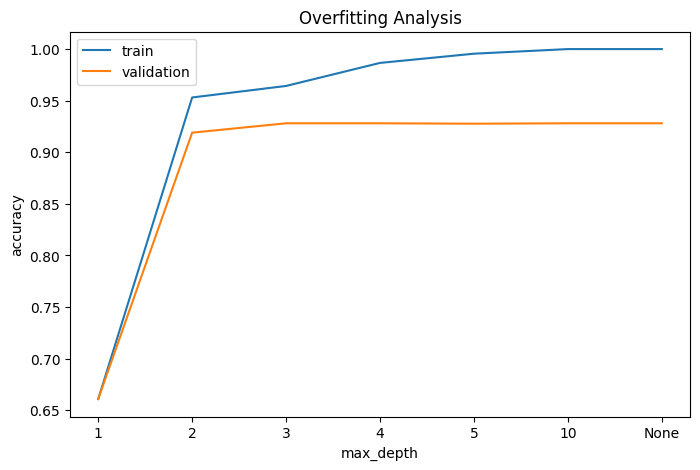

In [ ]:
# 시각화
import matplotlib.pyplot as plt 

plt.figure( figsize=(8,5) ) 
plt.plot( result["param_max_depth"].astype(str), result["mean_train_score"] ) 
plt.plot( result["param_max_depth"].astype(str), result["mean_test_score"] ) 
plt.xlabel("max_depth") 
plt.ylabel("accuracy") 
plt.title( "Overfitting Analysis" ) 
plt.legend([ "train", "validation" ]) 
plt.show()